Setup & Upload

In [1]:
# ================================================
# Multiple Linear Regression - Multi-Channel Marketing Analysis
# ================================================

!pip install pandas seaborn statsmodels matplotlib scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

# Upload dataset
from google.colab import files
print("📤 Please upload 'marketing_sales_data.csv'")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print(f"✅ Dataset loaded! Shape: {df.shape}")
df.head()

✅ Libraries imported!
📤 Please upload 'marketing_sales_data.csv'


Saving marketing_sales_data.csv to marketing_sales_data.csv
✅ Dataset loaded! Shape: (572, 5)


,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


Data Exploration & Cleaning

In [2]:
print("=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isna().sum())

# Drop missing values
df_clean = df.dropna().copy()
print(f"\nCleaned Shape: {df_clean.shape}")

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB
None

=== Missing Values ===
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

Cleaned Shape: (572, 5)


Exploratory Data Analysis + Multicollinearity Check
Python

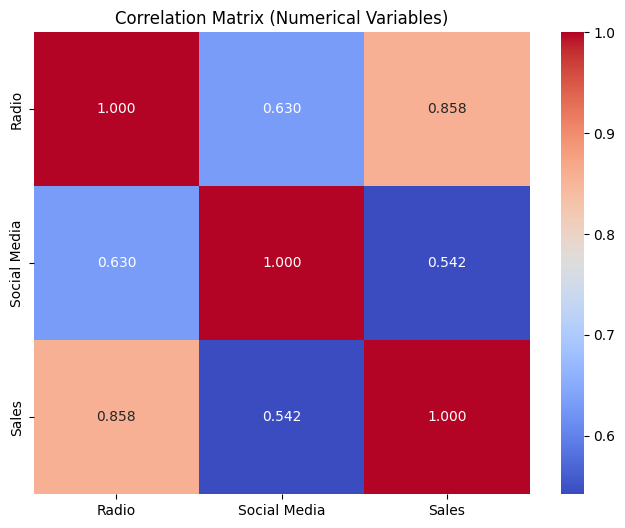

Variance Inflation Factor (VIF):
        Feature       VIF
0         const  4.713305
1         Radio  1.657894
2  Social Media  1.657894


In [3]:
# Numerical columns correlation
numerical_cols = ['Radio', 'Social Media', 'Sales']
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.3f')
plt.title("Correlation Matrix (Numerical Variables)")
plt.show()

# VIF for multicollinearity
X_num = df_clean[['Radio', 'Social Media']]
X_num = sm.add_constant(X_num)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_num.columns
vif_data["VIF"] = [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])]
print("Variance Inflation Factor (VIF):")
print(vif_data)

Build Multiple Linear Regression Model

In [6]:
# Using all numerical predictors + handling categorical if needed
# For simplicity and project requirement: Radio + Social Media as main predictors

df_clean = df_clean.rename(columns={'Social Media': 'Social_Media'})
model = ols('Sales ~ Radio + Social_Media', data=df_clean).fit()

print("=== Multiple Linear Regression Model Summary ===")
print(model.summary())

=== Multiple Linear Regression Model Summary ===
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     794.1
Date:                Sun, 21 Jun 2026   Prob (F-statistic):          2.18e-165
Time:                        14:06:01   Log-Likelihood:                -3003.1
No. Observations:                 572   AIC:                             6012.
Df Residuals:                     569   BIC:                             6025.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

Diagnostic Plots (Assumption Checking)

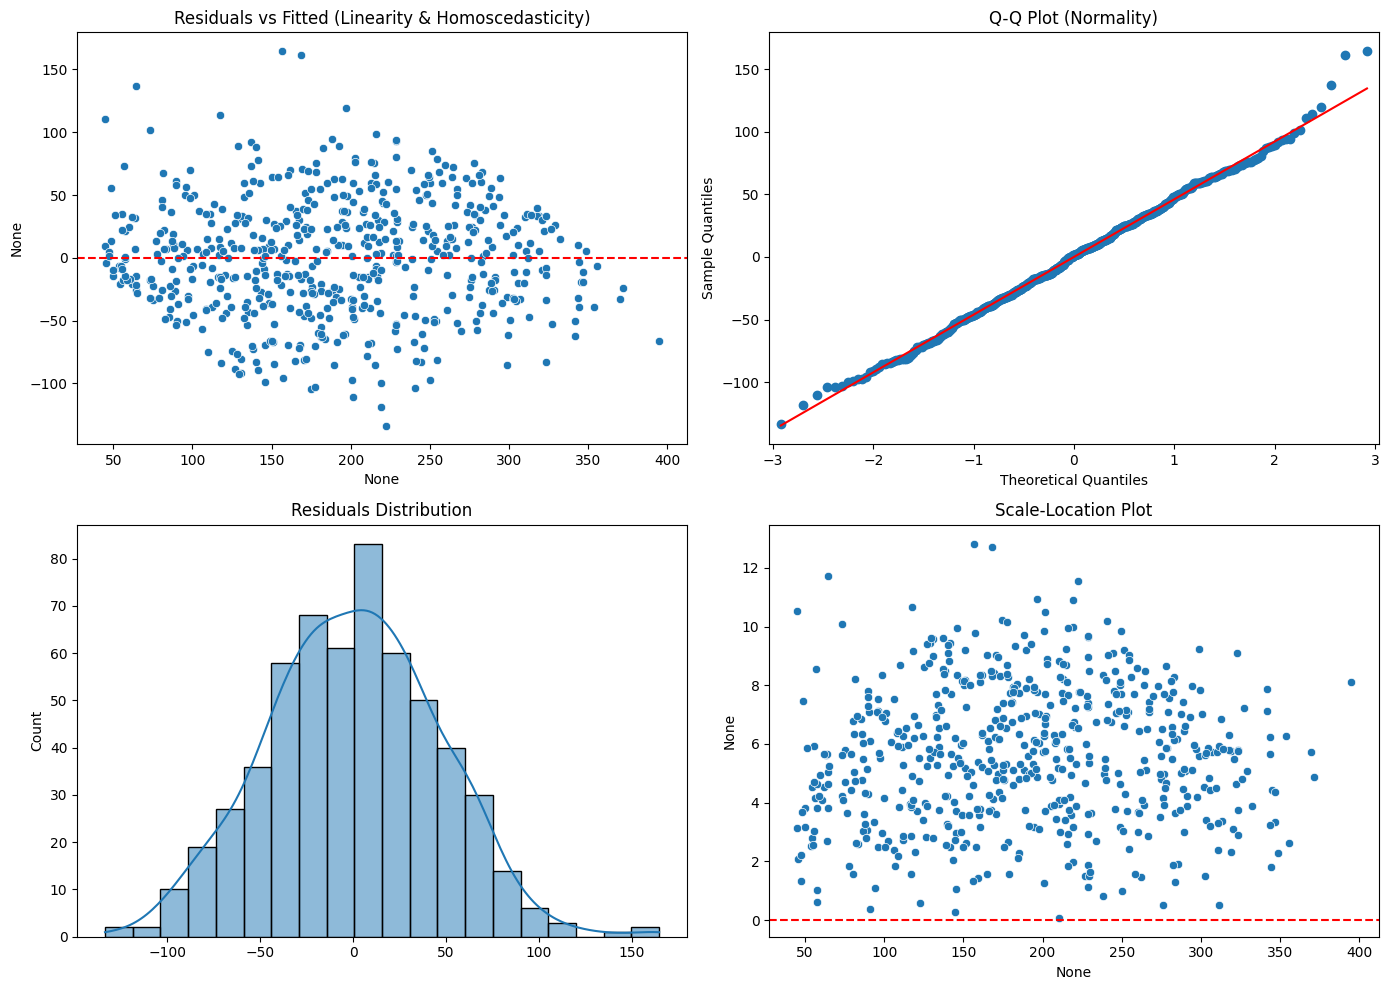

In [7]:
fitted = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted (Linearity & Homoscedasticity)')

plt.subplot(2, 2, 2)
sm.qqplot(residuals, line='s', ax=plt.gca())
plt.title('Q-Q Plot (Normality)')

plt.subplot(2, 2, 3)
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')

plt.subplot(2, 2, 4)
sns.scatterplot(x=fitted, y=np.sqrt(np.abs(residuals)))
plt.axhline(0, color='red', linestyle='--')
plt.title('Scale-Location Plot')

plt.tight_layout()
plt.show()

Interpretation & Business Recommendation

In [8]:
print("=== 📊 MODEL INTERPRETATION ===")
print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")

coef_radio = model.params['Radio']
coef_social = model.params.get('Social Media', None)
p_radio = model.pvalues['Radio']
p_social = model.pvalues.get('Social Media', None)

print(f"\nCoefficient for Radio: {coef_radio:.4f} (p-value: {p_radio:.4f})")
if coef_social is not None:
    print(f"Coefficient for Social Media: {coef_social:.4f} (p-value: {p_social:.4f})")

print("\n💼 BUSINESS RECOMMENDATION:")
print("• Holding other channels constant,")
print(f"  Each additional $1M in Radio advertising is associated with ${coef_radio:.2f}M increase in Sales.")
if coef_social is not None and p_social < 0.05:
    print(f"  Social Media also shows a positive impact (${coef_social:.2f}M per $1M).")
print("\n• Recommendation: Prioritize **Radio** as the strongest driver. Allocate more budget to Radio while monitoring Social Media efficiency.")

=== 📊 MODEL INTERPRETATION ===
Adjusted R-squared: 0.7353

Coefficient for Radio: 8.2843 (p-value: 0.0000)

💼 BUSINESS RECOMMENDATION:
• Holding other channels constant,
  Each additional $1M in Radio advertising is associated with $8.28M increase in Sales.

• Recommendation: Prioritize **Radio** as the strongest driver. Allocate more budget to Radio while monitoring Social Media efficiency.
